# Comprehensive OpenCV Assignment

Follow the instructions in each section and write your code in the provided empty cells using the specified file names.

## 1. Reading Images and Videos
**Task:**
1. Read the image `cats.jpg` and display it.
2. Read the video `dog.mp4` and display it frame by frame. Ensure the video window closes when the 'd' key is pressed.

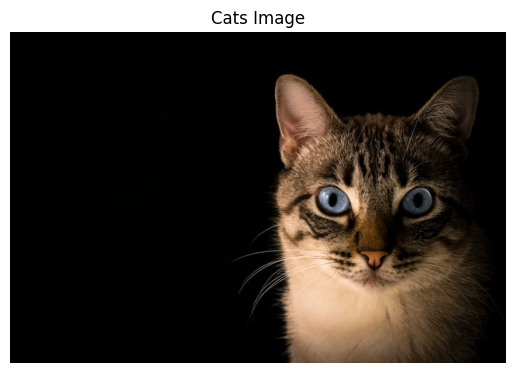

In [20]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

image = cv2.imread("/content/sample_data/cat.jpg")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Cats Image")
plt.axis("off")
plt.show()

# cap = cv2.VideoCapture("/content/sample_data/dog.mp4")
# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break
#     cv2_imshow(frame)

#     if cv2.waitKey(25) & 0xFF == ord('d'):
#         break

# cap.release()
# cv2.destroyAllWindows()
# Takes up a lot of memory which make the notebook exceed 100Mb file push limit on Gitbash therefore commented out the code for video frames

## 2. Drawing and Text
**Task:**
1. Create a blank image of size $500 \times 500$ with 3 color channels.
2. Paint a portion of the image red ($[200:300, 300:400]$).
3. Draw a green rectangle from $(0,0)$ to the center of the image.
4. Draw a red circle at the center with a radius of 40.
5. Draw a white line from $(100, 250)$ to $(300, 400)$.



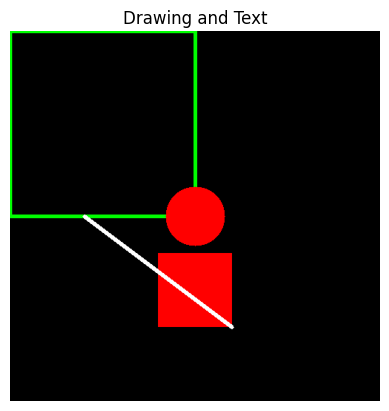

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((500, 500, 3), dtype=np.uint8)

img[300:400,200:300] = (0, 0, 255)

cv2.rectangle(img, (0, 0), (250, 250), (0, 255, 0), 3)

cv2.circle(img, (250, 250), 40, (0, 0, 255), -1)

cv2.line(img, (100, 250), (300, 400), (255, 255, 255), 3)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.title("Drawing and Text")
plt.show()

## 3. Basic Image Functions
**Task:**
1. Load `park.jpg`.
2. Convert it to grayscale.
3. Apply Gaussian Blur with a $(7,7)$ kernel.
4. Perform Canny Edge detection on the blurred image.


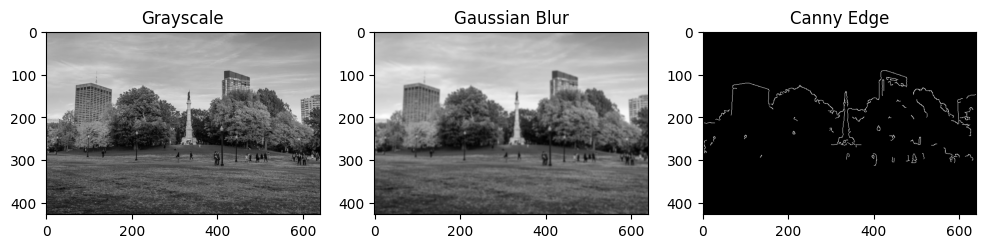

In [22]:
# Write your code here
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/sample_data/park.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7,7), 0)

edges = cv2.Canny(blur, 100, 200)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(1,3,2)
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blur")

plt.subplot(1,3,3)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge")

plt.show()

## 4. Image Transformations
**Task:**
1. Create a function `translate(img, x, y)` to shift an image.
2. Create a function `rotate(img, angle, rotPoint=None)` to rotate an image.
3. Apply a flip transformation to `park.jpg`.

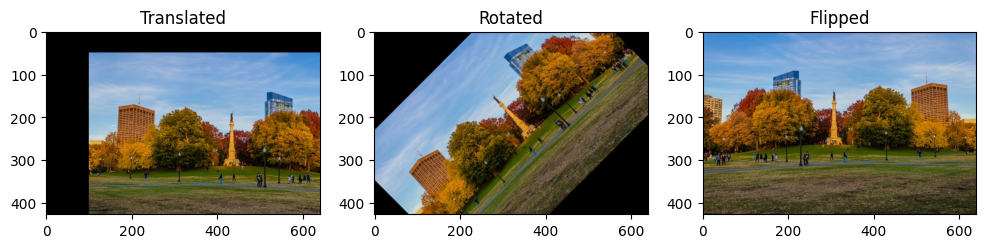

In [23]:
# Write your code here
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/sample_data/park.jpg")

rows, cols = img.shape[:2]

def translate(img, x, y):
    matrix = np.float32([
        [1, 0, x],
        [0, 1, y]
    ])

    shifted = cv2.warpAffine(img, matrix, (cols, rows))
    return shifted

def rotate(img, angle, rotPoint=None):

    (height, width) = img.shape[:2]

    if rotPoint is None:
        rotPoint = (width//2, height//2)

    matrix = cv2.getRotationMatrix2D(rotPoint, angle, 1.0)

    rotated = cv2.warpAffine(img, matrix, (width, height))

    return rotated

translated = translate(img, 100, 50)

rotated = rotate(img, 45)

flipped = cv2.flip(img, 1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
plt.title("Translated")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.title("Flipped")

plt.show()

## 5. Contour Detection
**Task:**
1. Load `cats.jpg`.
2. Convert to grayscale and apply Gaussian blur.
3. Find the edges using Canny.
4. Use `cv.findContours` to find all contours.
5. Print the count and draw them on a blank image.

141 contour(s) found!


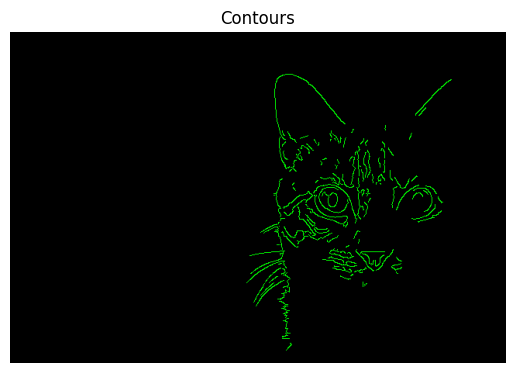

In [24]:
# Write your code here
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/sample_data/cat.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

canny = cv2.Canny(blur, 125, 175)

contours, hierarchies = cv2.findContours(
    canny,
    cv2.RETR_LIST,
    cv2.CHAIN_APPROX_SIMPLE
)

print(f'{len(contours)} contour(s) found!')

blank = np.zeros(img.shape, dtype='uint8')

cv2.drawContours(blank, contours, -1, (0,255,0), 1)

plt.imshow(cv2.cvtColor(blank, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Contours")
plt.show()

## 6. Color Spaces
**Task:**
1. Load `park.jpg`.
2. Convert and display in: Gray, HSV,and RGB.

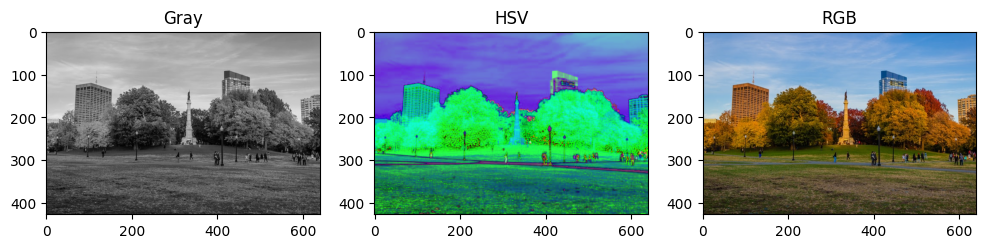

In [25]:
# Write your code here
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/sample_data/park.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Gray")

plt.subplot(1,3,2)
plt.imshow(hsv)
plt.title("HSV")

plt.subplot(1,3,3)
plt.imshow(rgb)
plt.title("RGB")

plt.show()

## 7. Smoothing and Blurring
**Task:**
1. Load `cats.jpg`.
2. Apply Averaging, Gaussian and Median Blurs

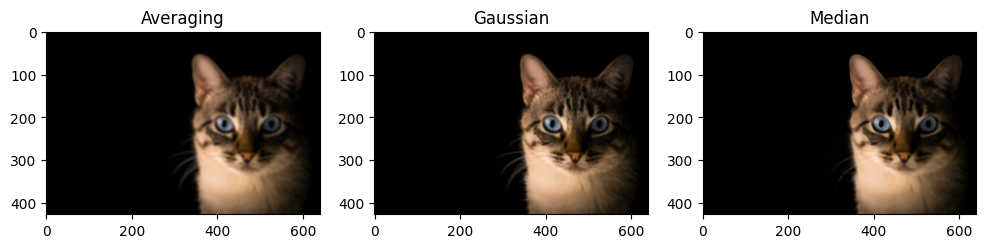

In [26]:
# Write your code here
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/sample_data/cat.jpg")

average = cv2.blur(img, (7,7))

gaussian = cv2.GaussianBlur(img, (7,7), 0)

median = cv2.medianBlur(img, 7)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(average, cv2.COLOR_BGR2RGB))
plt.title("Averaging")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
plt.title("Gaussian")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))
plt.title("Median")

plt.show()

## 8. Bitwise Operations
**Task:**
1. Create a $400 \times 400$ blank image.
2. Create a rectangle and a circle on separate blank images.
3. Perform Bitwise AND, OR, XOR, and NOT.

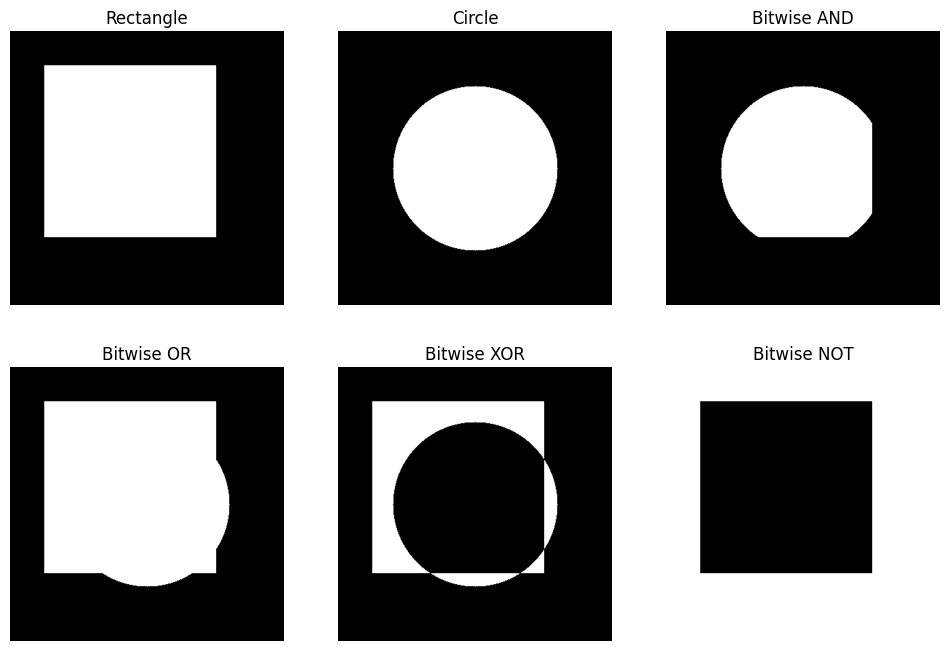

In [27]:
# Write your code here
import cv2
import numpy as np
from matplotlib import pyplot as plt

img1 = np.zeros((400, 400), dtype="uint8")
img2 = np.zeros((400, 400), dtype="uint8")

cv2.rectangle(img1, (50, 50), (300, 300), 255, -1)

cv2.circle(img2, (200, 200), 120, 255, -1)

bitwise_and = cv2.bitwise_and(img1, img2)
bitwise_or = cv2.bitwise_or(img1, img2)
bitwise_xor = cv2.bitwise_xor(img1, img2)
bitwise_not = cv2.bitwise_not(img1)

titles = [
    "Rectangle",
    "Circle",
    "Bitwise AND",
    "Bitwise OR",
    "Bitwise XOR",
    "Bitwise NOT"
]

images = [
    img1,
    img2,
    bitwise_and,
    bitwise_or,
    bitwise_xor,
    bitwise_not
]

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.show()

## 9. Thresholding
**Task:**
1. Load `cats.jpg` and convert to grayscale.
2. Apply Simple Thresholding (Binary and Inverse).

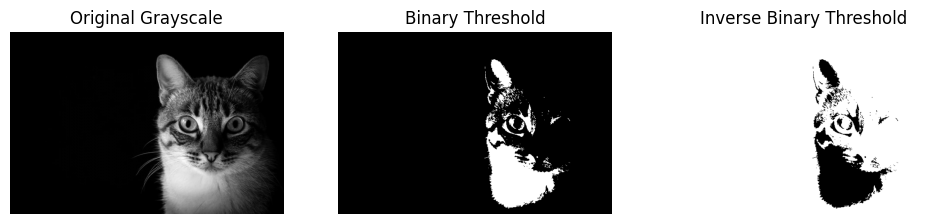

In [28]:
# Write your code here
import cv2
from matplotlib import pyplot as plt

img = cv2.imread("/content/sample_data/cat.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

_, inverse_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

titles = [
    "Original Grayscale",
    "Binary Threshold",
    "Inverse Binary Threshold"
]

images = [
    gray,
    binary_thresh,
    inverse_thresh
]

plt.figure(figsize=(12,4))

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.show()